In [32]:
%pip install matplotlib 

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 45.2 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 41.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 50.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.chdir("..")

In [2]:
os.getcwd()

'c:\\Users\\vynde\\Documents\\GitHub\\AlgoTrader'

In [3]:
import backtrader as bt
import pandas as pd
from datetime import datetime, timedelta, time, date, timezone, tzinfo
#from trader.indicators.bt_directional_change import DirectionalChange
from trader.trader import Trader


In [4]:
os.chdir("trader")

In [48]:
class DirectionalChange(bt.Indicator):
    lines = ('extreme', 'overshoot')
    params = (
        ('sigma', 0.0001),
        ('high_colname', 'high'),
        ('low_colname', 'low'),
    )


    def __init__(self):
        # TODO: add timezone support
        # TODO: specify the data source
        self.high = getattr(self.data, self.p.high_colname)
        self.low = getattr(self.data, self.p.low_colname)

        self.up_zig = False
        self.down_zig = False
        self.last_overshoot = 0 
        self.initial_timestamp = None
        self.initial_high = None
        self.initial_low = None
        self.timestamp = None

    def next(self):
        if not self.initial_high or not self.initial_low:
            self.initial_high = self.high[0]
            self.initial_low = self.low[0]

        # trend initialization / wait for first overshoot event
        if not (self.up_zig or self.down_zig):
            
            if self.low <= self.initial_high - self.p.sigma:
                # save time/val from current overshoot event
                self.down_zig = True
                self.l.overshoot[0] = self.low[0]

            elif self.high >= self.initial_low + self.p.sigma:
                # save time/val from current overshoot event
                self.up_zig = True
                self.l.overshoot[0] = self.high[0]

        elif self.up_zig:
            if overshoot_event := self.high[0] > self.l.overshoot[0]:
                self.l.overshoot[0] = self.high[0]

            elif self.low <= self.l.overshoot[0] - self.p.sigma:
                self.down_zig = True
                self.up_zig = False
                self.l.extreme[0] = self.l.overshoot[0]
                self.l.overshoot[0] = self.low[0]

        elif self.down_zig:
            if undershoot_event := self.low[0] < self.l.overshoot[0]:
                self.l.overshoot[0] = self.low[0]
            elif self.high >= self.l.overshoot[0] + self.p.sigma:
                self.up_zig = True
                self.down_zig = False
                self.l.extreme[0] = self.l.overshoot[0]
                self.l.overshoot[0] = self.high[0]


In [46]:
class TestStrategy(bt.Strategy):

    def log(self, txt, dt=None):
        ''' Logging function for this strategy'''
        dt = dt or self.data.datetime.datetime()
        print(dt.isoformat(), txt)

    def __init__(self):
        self.dc = DirectionalChange()
        pass

    def next(self):
        self.log(f'Close, {self.data.close[0]}')
        print(self.dc.l.overshoot[0])



In [7]:
trader = Trader()
trader.add_broker('oanda')
trader.add_data('EUR_USD', start='2025-01-20', end='2025-01-21', granularities='1min')


Fetching from ABCMeta: EUR_USD data from 2025-01-20 to 2025-01-21 with granularity 1min and price M


In [14]:
df = trader.data[0].df

In [52]:
cerebro = bt.Cerebro()

cerebro.addstrategy(TestStrategy)

data = bt.feeds.PandasData(dataname=df)

# Add the Data Feed to Cerebro
cerebro.adddata(data)

cerebro.run()

2025-01-20T00:00:00 Close, 1.02822
1.02806
2025-01-20T00:01:00 Close, 1.02822
nan
2025-01-20T00:02:00 Close, 1.02806
nan
2025-01-20T00:03:00 Close, 1.02786
nan
2025-01-20T00:04:00 Close, 1.028
nan
2025-01-20T00:05:00 Close, 1.02819
nan
2025-01-20T00:06:00 Close, 1.02822
nan
2025-01-20T00:07:00 Close, 1.0282
nan
2025-01-20T00:08:00 Close, 1.02836
nan
2025-01-20T00:09:00 Close, 1.02838
nan
2025-01-20T00:10:00 Close, 1.02839
nan
2025-01-20T00:11:00 Close, 1.02838
nan
2025-01-20T00:12:00 Close, 1.0289
nan
2025-01-20T00:13:00 Close, 1.02901
nan
2025-01-20T00:14:00 Close, 1.029
nan
2025-01-20T00:15:00 Close, 1.02874
nan
2025-01-20T00:16:00 Close, 1.02869
nan
2025-01-20T00:17:00 Close, 1.02866
nan
2025-01-20T00:18:00 Close, 1.02872
nan
2025-01-20T00:19:00 Close, 1.02871
nan
2025-01-20T00:20:00 Close, 1.02876
nan
2025-01-20T00:21:00 Close, 1.02865
nan
2025-01-20T00:22:00 Close, 1.02862
nan
2025-01-20T00:23:00 Close, 1.0286
nan
2025-01-20T00:24:00 Close, 1.02852
nan
2025-01-20T00:25:00 Close, 1

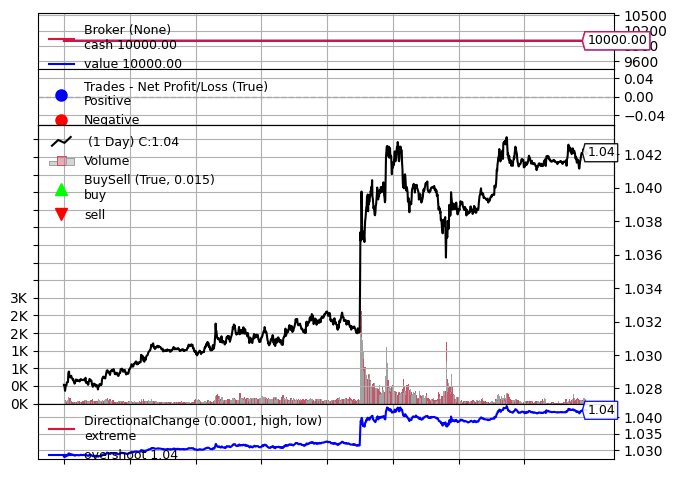

[[<Figure size 640x480 with 5 Axes>]]

In [37]:
%matplotlib inline
cerebro.plot(iplot=False)